In [119]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [120]:
def f(x):
    return 3*x**2 - 4*x +5

In [121]:
f(3)

20

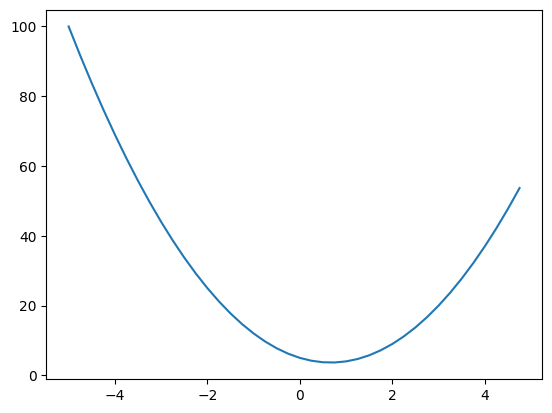

In [122]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [123]:
h = 0.0000001
x = 3.0
(f(x + h) - f(x))/h

14.000000305713911

In [124]:
# lets get little complex
a = 2.0
b = -3.0
c = 10.0

h = 0.0001

d1 = a*b + c
b+=h
d2 = a*b + c
print('d1',d1)
print('d2',d2)
print('slope',(d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [125]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label = ""):
        self.data = data
        self._prev = _children
        self._op = _op
        self.label = label
        self.grad =  0
        self._backward = lambda:None


    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out
    

    def __radd__(self, other):
        return self + other
        

    def __mul__(self,other):
        other = other if  isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out
    
    def __rmul__(self,other):
        return self * other
    
    def __sub__(self,other):
        return self + (-other)
    
    def __neg__(self):
        return self * -1
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other,(int,float)), "only supporting int/float powers for now "
        out = Value(self.data**other,(self,),f"**{other}")

        def _backward():
            self.grad = other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out

    def __iter__(self):
        for child in self._prev:
            yield  child

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = _backward

        return out


    def backward(self):

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),"exp")
        def _backward():
            self.grad += out.data  * out.grad
        out._backward = _backward
        return out


a = Value(2.0,label='a')
b = Value(-3.0) ; b.label = 'b'
c = Value(10) ; c.label = "c"
e = a*b; e.label = "e"
d  = e + c ;d.label = "d"
f = Value(-2.0,label="f")
l = d * f ; l.label = "L"
l

Value(data=-8.0)

In [126]:
a = Value(2.0)
-a

Value(data=-2.0)

In [127]:
a

Value(data=2.0)

In [128]:
l._prev

(Value(data=4.0), Value(data=-2.0))

In [157]:
from graphviz import Digraph

def trace(root):
    nodes,edges  = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            # print("\naddding this to node ",v)
            # print("Node",nodes)
            for child in v._prev:
                # print("\nadding these to edges",child,v)
                edges.add((child,v))
                # print("Edges",edges)
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,create a reactangular ('recored') node for it 
        dot.node(name=uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it 
            dot.node(name = uid + n._op,label = n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op )
    return dot



In [130]:
l.grad = 1.00
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

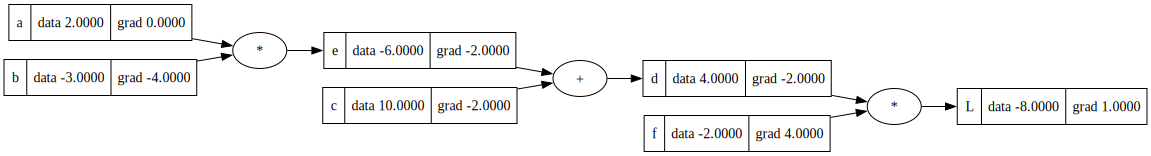

In [131]:
draw_dot(l)

In [132]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad



e = a*b
d  = e + c
l = d * f 

l.data

-7.286496

In [133]:
def lol():

    h = 0.001

    a = Value(2.0,label='a')
    b = Value(-3.0) ; b.label = 'b'
    c = Value(10) ; c.label = "c"
    e = a*b; e.label = "e"
    d  = e + c ;d.label = "d"
    f = Value(-2.0,label="f")
    l = d * f ; l.label = "L"
    L1 = l.data

    a = Value(2.0,label='a')
    b = Value(-3.0) ; b.label = 'b'
    b.data += h
    c = Value(10) ; c.label = "c"
    e = a*b; e.label = "e"
    d  = e + c ;d.label = "d"
    f = Value(-2.0,label="f") 
    l = d * f ; l.label = "L"
    L2 = l.data

    print((L2-L1)/h)

In [134]:
lol()

-3.9999999999995595


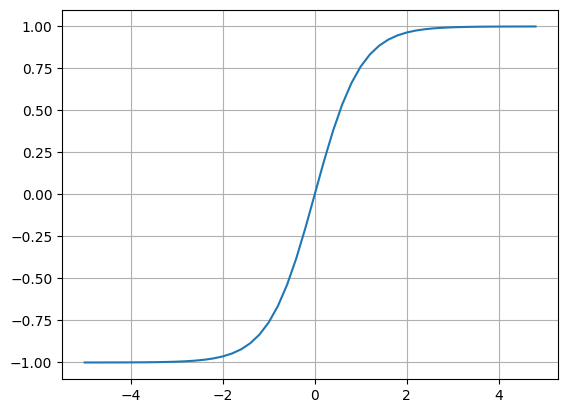

In [135]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid()

In [136]:
# inputs x1 x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')

# weights w1 w2
w1 = Value(-3.0,label="w1")
w2 = Value(1.0,label="w2")

# bias of the neuron
b = Value(6.8813735870195432,label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2 ; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1 + x2w2"

n = x1w1x2w2 + b ; n.label = "n"

o = n.tanh() ; o.label = "o"

In [137]:
# o.grad = 1.0
# n.grad = 0.5
# b.grad = 0.5
# x1w1x2w2.grad = 0.5
# x1w1.grad = 0.5
# x2w2.grad = 0.5
# x1.grad = -1.5
# w1.grad = 1
# x2.grad = 0.5
# w2.grad = 0.0


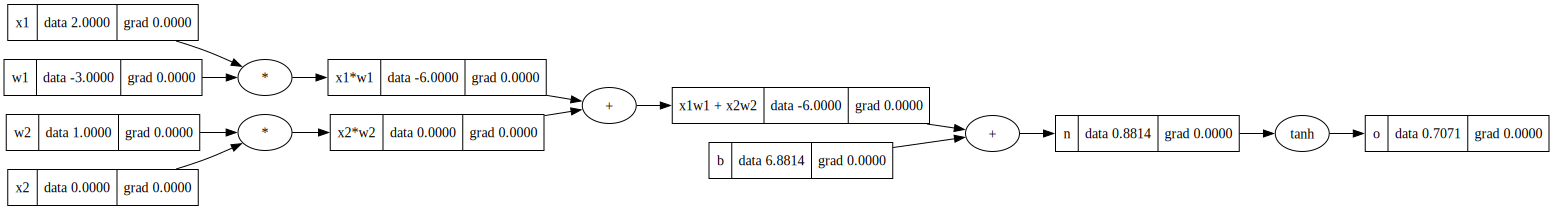

In [138]:
draw_dot(o)

In [139]:
o.grad = 1.0
o._backward()

In [140]:
n._backward()

In [141]:
x1w1x2w2._backward()

In [142]:
x1w1._backward(),x2w2._backward()

(None, None)

In [143]:
o.backward()


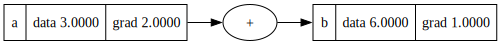

In [144]:
a = Value(3.0,label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

In [145]:
1 + a

Value(data=4.0)

In [146]:
2* a

Value(data=6.0)

In [147]:
a.exp()

Value(data=20.085536923187668)

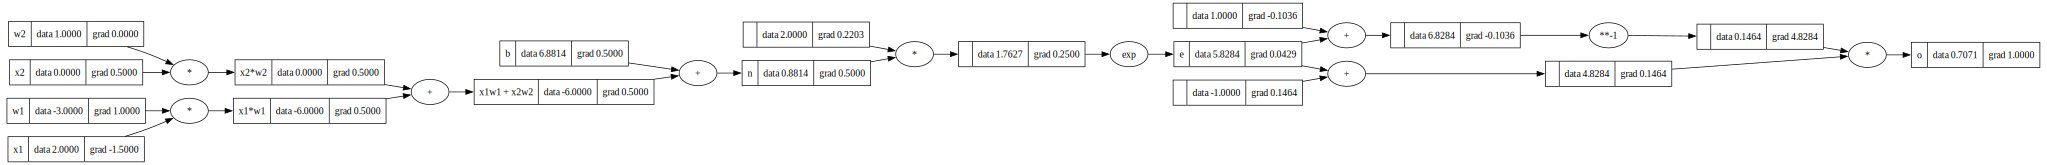

In [148]:
# inputs x1 x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')

# weights w1 w2
w1 = Value(-3.0,label="w1")
w2 = Value(1.0,label="w2")

# bias of the neuron
b = Value(6.8813735870195432,label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2 ; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1 + x2w2"

n = x1w1x2w2 + b ; n.label = "n"

e = (2*n).exp();e.label = 'e'
o = (e-1)/(e+1);o.label ='o'

o.backward()
draw_dot(o)

In [149]:
import torch

In [150]:
x1 = torch.tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double() ; w2.requires_grad = True
b = torch.tensor([6.8813735890195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()

print('---')
print(f"x2: {x2.grad.item()}")
print(f"w2: {w2.grad.item()}")
print(f"x1: {x1.grad.item()}")
print(f"w1: {w1.grad.item()}")

0.7071066904050358
---
x2: 0.5000001283844369
w2: 0.0
x1: -1.5000003851533106
w1: 1.0000002567688737


In [151]:
import random
# Generates a random float between 10 and 50
print(random.uniform(10, 50)) 


14.038092338465479


In [158]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        # print("W",self.w,"b",self.b)

    def __call__(self,x):
        # w*X +b 
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

class Layer:

    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs


class MLP:

    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

        


In [ ]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x),n(x)

Value(data=-0.08005998131172397)

In [166]:
# draw_dot(n(x))

In [174]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

y_pred = [n(x) for x in xs]
y_pred

[Value(data=-0.08005998131172397),
 Value(data=-0.8741407504300833),
 Value(data=-0.6480789642831858),
 Value(data=-0.5171586195710138)]

In [ ]:
loss = [(ygt - yout)**2  for ygt,yout in zip(y_pred,ys)]